# R FastCAR vs `pyfastcar` -- bit-exact ambient-RNA correction

This notebook runs both the original R `FastCAR` (via `Rscript`) and our pure-Python
port `pyfastcar` on the **same raw 10x dataset**, then uses **omicverse** to visualize
that the two implementations agree.

FastCAR estimates ambient RNA from the **empty droplets** of the *raw, unfiltered*
count matrix and subtracts it -- gene by gene -- from the real cells. So unlike a
filtered dataset, the input here is a true raw 10x matrix (`data/pbmc1k_raw.h5ad`,
a subset of 10x Genomics' `pbmc_1k_v3` raw feature-barcode matrix) that still
contains empty droplets.

Comparisons performed:

1. **Ambient profile** -- the per-gene `gMax` amount FastCAR subtracts must match
   R element-for-element.
2. **Corrected matrix** -- the integer corrected cell matrix must be bit-identical.
3. **Threshold profiling** -- `describe.ambient.RNA.sequence` table must match.

Since FastCAR is fully deterministic (no RNG anywhere), the agreement is expected
to be **bit-exact**.

In [1]:
from __future__ import annotations

import json
import os
import subprocess
from pathlib import Path

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.sparse as sp
import omicverse as ov

import pyfastcar as fc

ov.plot_set()
RSCRIPT = "/scratch/users/steorra/env/CMAP/bin/Rscript"
DRIVER  = Path("r_driver_fastcar.R").resolve()

WORK = Path("./compare_out"); WORK.mkdir(exist_ok=True)
print("omicverse", ov.__version__, "-- pyfastcar", fc.__version__)

/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)


🔬 Starting plot initialization...
🧬 Detecting GPU devices…
🚫 No GPU devices found (CUDA/MPS/ROCm/XPU)

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.2.1rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.

omicverse 2.2.1rc1 -- pyfastcar 0.1.0


## 1. Load the raw 10x dataset

`data/pbmc1k_raw.h5ad` is a subset of the 10x Genomics `pbmc_1k_v3` **raw**
feature-barcode matrix: 1174 real cells, 1500 non-empty empty droplets, and
100 all-zero unused barcodes. The `droplet_type` column records which is which.

In [2]:
raw = ad.read_h5ad("../data/pbmc1k_raw.h5ad")
tot = np.asarray(raw.X.sum(1)).ravel() if sp.issparse(raw.X) else raw.X.sum(1)
print(raw)
print(raw.obs["droplet_type"].value_counts())

# Filtered cell matrix = the real cells (total UMI >= 1000).
cells = raw[tot >= 1000].copy()
print("raw droplets:", raw.n_obs, " real cells:", cells.n_obs)

AnnData object with n_obs × n_vars = 2774 × 4000
    obs: 'droplet_type'
droplet_type
empty     1500
cell      1174
unused     100
Name: count, dtype: int64
raw droplets: 2774  real cells: 1171


## 2. Dump genes x droplets TSVs for the R driver

FastCAR (and 10x CellRanger) store data **genes x droplets**, the transpose of
AnnData's cells x genes layout. We write both matrices out so the R driver
consumes exactly the same counts.

In [3]:
empty_cutoff, contam_cutoff = 100, 0.005

full_tsv = WORK / "full_counts.tsv"
cell_tsv = WORK / "cell_counts.tsv"
if not full_tsv.exists():
    fullX = raw.X.T.toarray() if sp.issparse(raw.X) else np.asarray(raw.X).T
    pd.DataFrame(fullX, index=raw.var_names,
                 columns=raw.obs_names).to_csv(full_tsv, sep="\t")
if not cell_tsv.exists():
    cellX = cells.X.T.toarray() if sp.issparse(cells.X) else np.asarray(cells.X).T
    pd.DataFrame(cellX, index=cells.var_names,
                 columns=cells.obs_names).to_csv(cell_tsv, sep="\t")
print("full ->", full_tsv, " cell ->", cell_tsv)

full -> compare_out/full_counts.tsv  cell -> compare_out/cell_counts.tsv


## 3. Run R FastCAR via Rscript

`r_driver_fastcar.R` runs `determine.background.to.remove` ->
`remove.background` -> `describe.ambient.RNA.sequence` and dumps the
ambient profile, corrected matrix and profiling table.

In [4]:
r_out = WORK / "r_out"; r_out.mkdir(exist_ok=True)
if not (r_out / "ambient_profile.tsv").exists():
    env = os.environ.copy()
    gcc = "/share/software/user/open/gcc/14.2.0"
    if os.path.isdir(gcc):
        env["PATH"] = f"{gcc}/bin:" + env.get("PATH", "")
        env["LD_LIBRARY_PATH"] = f"{gcc}/lib64:" + env.get("LD_LIBRARY_PATH", "")
    proc = subprocess.run(
        [RSCRIPT, str(DRIVER), str(full_tsv), str(cell_tsv), str(r_out),
         str(empty_cutoff), str(contam_cutoff)],
        env=env, capture_output=True, text=True,
    )
    print(proc.stdout[-800:])
    if proc.returncode != 0:
        print("STDERR:\n", proc.stderr[-1500:])
        raise RuntimeError("R driver failed")

r_profile = pd.read_csv(r_out / "ambient_profile.tsv", sep="\t")
r_corrected = pd.read_csv(r_out / "corrected_matrix.tsv", sep="\t", index_col=0)
r_desc = pd.read_csv(r_out / "ambient_description.tsv", sep="\t", index_col=0)
r_meta = json.loads((r_out / "meta.json").read_text())
print("R: genes corrected =", r_meta["nGenesCorrected"],
      " recommended cutoff =", r_meta["recommendedCutoff"])

[R] reading full matrix compare_out/full_counts.tsv
[R] reading cell matrix compare_out/cell_counts.tsv
[R] full = 4000 x 2774, cells = 4000 x 1171
[R] determine.background.to.remove()
[R] remove.background()
[R] describe.ambient.RNA.sequence()
[R] wrote outputs to compare_out/r_out (genes corrected = 121, rec. cutoff = 100)



R: genes corrected = 121  recommended cutoff = 100


## 4. Run `pyfastcar` on the same matrices

We call the low-level `determine_background_to_remove` / `remove_background`
on the genes x droplets matrices -- the exact same orientation R used.

In [5]:
full_df = pd.read_csv(full_tsv, sep="\t", index_col=0)
cell_df = pd.read_csv(cell_tsv, sep="\t", index_col=0)

py_profile = fc.determine_background_to_remove(
    full_df, cell_df,
    empty_droplet_cutoff=empty_cutoff,
    contamination_chance_cutoff=contam_cutoff,
)
py_corrected = fc.remove_background(cell_df, py_profile)
py_desc = fc.describe_ambient_rna_sequence(
    full_df, start=50, stop=500, by=25,
    contamination_chance_cutoff=contam_cutoff,
)
print("pyfastcar: genes corrected =", int((py_profile > 0).sum()))

pyfastcar: genes corrected = 121


## 5. Bit-exact check -- ambient profile

The per-gene amount FastCAR subtracts (`gMax` for contaminating genes, 0
otherwise) must match R element-for-element.

In [6]:
prof_cmp = pd.DataFrame({
    "R": r_profile["profile"].to_numpy().astype(np.int64),
    "py": py_profile.to_numpy().astype(np.int64),
}, index=py_profile.index)
prof_exact = np.array_equal(prof_cmp["R"].to_numpy(), prof_cmp["py"].to_numpy())
max_abs = int(np.max(np.abs(prof_cmp["R"] - prof_cmp["py"])))
print(f"ambient profile bit-exact: {prof_exact}   max |R - py| = {max_abs}")
prof_cmp[prof_cmp["R"] > 0].sort_values("R", ascending=False).head(10)

ambient profile bit-exact: True   max |R - py| = 0


,R,py
gene,,
MT-CO3,18,18
MT-CO1,14,14
MT-ATP6,12,12
MT-CO2,10,10
MT-ND3,7,7
MT-ND4,6,6
S100A9,6,6
MT-CYB,5,5
TMSB4X,3,3


## 6. Bit-exact check -- corrected matrix

The corrected integer cell matrix (genes x cells) must be identical.

In [7]:
py_corr_arr = py_corrected.to_numpy().astype(np.int64)
r_corr_arr = r_corrected.to_numpy().astype(np.int64)
corr_exact = np.array_equal(py_corr_arr, r_corr_arr)
n_diff = int(np.count_nonzero(py_corr_arr != r_corr_arr))
print(f"corrected matrix bit-exact: {corr_exact}   "
      f"differing entries: {n_diff} / {py_corr_arr.size}")

corrected matrix bit-exact: True   differing entries: 0 / 4684000


## 7. Bit-exact check -- threshold profiling table

`describe.ambient.RNA.sequence` reports, for a sweep of empty-droplet
cutoffs, how many genes would be flagged as contaminating.

In [8]:
desc_cmp = py_desc.join(r_desc, lsuffix="_py", rsuffix="_R")
cols = ["nEmptyDroplets", "genesInBackground", "genesContaminating"]
desc_exact = all(
    np.array_equal(py_desc[c].to_numpy().astype(np.int64),
                   r_desc[c].to_numpy().astype(np.int64))
    for c in cols
)
print("threshold-profiling table bit-exact:", desc_exact)
print("recommended cutoff -- R:", r_meta["recommendedCutoff"],
      " py:", fc.recommend_empty_cutoff(py_desc))
desc_cmp.head()

threshold-profiling table bit-exact: True
recommended cutoff -- R: 100  py: 100


,nEmptyDroplets_py,genesInBackground_py,genesContaminating_py,nEmptyDroplets_R,genesInBackground_R,genesContaminating_R
emptyDropletCutoff,,,,,,
50,1432,1600,120,1432,1600,120
75,1432,1600,120,1432,1600,120
100,1433,1602,121,1433,1602,121
125,1433,1602,121,1433,1602,121
150,1433,1602,121,1433,1602,121


## 8. Visualize the ambient profile -- per-gene gMax

The genes FastCAR corrects are the ones whose `frC` (fraction of empty
droplets that contain the gene) clears the contamination cutoff. R and
Python overlay exactly.

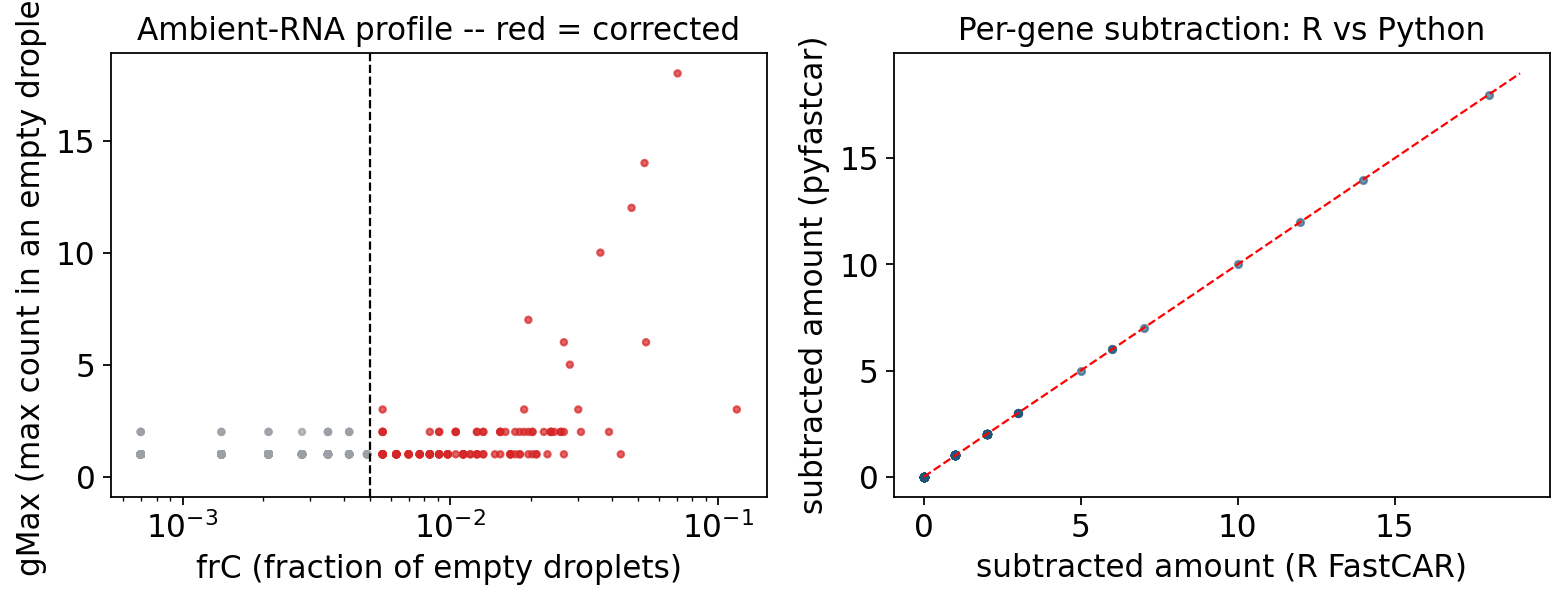

In [9]:
_, table = fc.determine_background_to_remove(
    full_df, cell_df, empty_droplet_cutoff=empty_cutoff,
    contamination_chance_cutoff=contam_cutoff, return_table=True)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(table["frC"], table["gMax"], s=8,
                c=np.where(table["selected"], "#d62728", "#9aa0a6"), alpha=0.7)
axes[0].axvline(contam_cutoff, ls="--", c="k", lw=1)
axes[0].set_xlabel("frC (fraction of empty droplets)")
axes[0].set_ylabel("gMax (max count in an empty droplet)")
axes[0].set_xscale("log")
axes[0].set_title("Ambient-RNA profile -- red = corrected")

axes[1].scatter(r_profile["profile"], py_profile.to_numpy(), s=10, alpha=0.6)
lim = [0, max(r_profile["profile"].max(), py_profile.max()) + 1]
axes[1].plot(lim, lim, "r--", lw=1)
axes[1].set_xlabel("subtracted amount (R FastCAR)")
axes[1].set_ylabel("subtracted amount (pyfastcar)")
axes[1].set_title("Per-gene subtraction: R vs Python")
plt.tight_layout(); plt.show()

## 9. Effect of the correction on the AnnData -- `correct_anndata`

The `correct_anndata` wrapper does the whole pipeline in the natural
cells x genes orientation and records diagnostics in `.uns['fastcar']`.

total counts removed as ambient RNA: 250709
genes corrected: 121


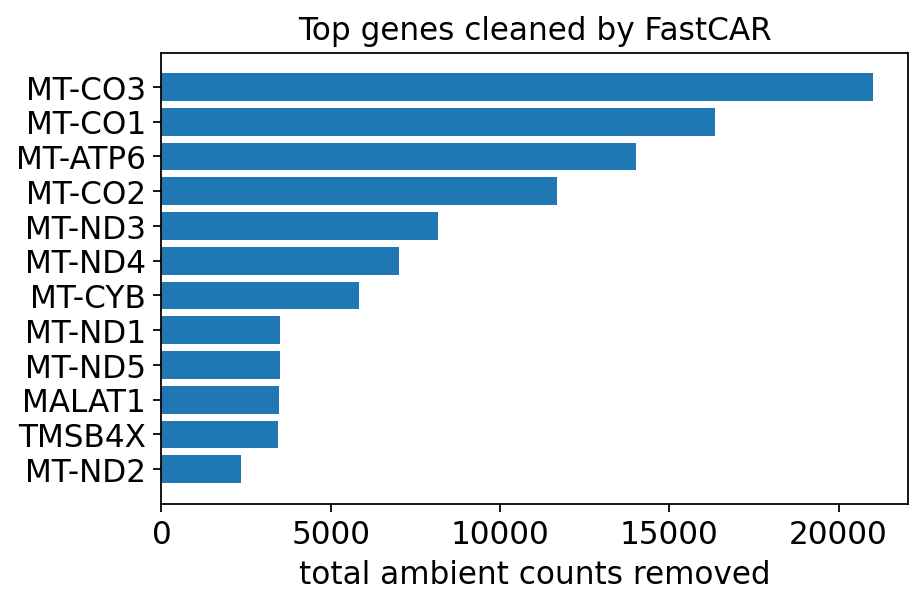

In [10]:
corrected_ad = fc.correct_anndata(
    raw, cells, empty_droplet_cutoff=empty_cutoff,
    contamination_chance_cutoff=contam_cutoff)

before = np.asarray(cells.X.sum(0)).ravel() if sp.issparse(cells.X) else cells.X.sum(0)
after  = np.asarray(corrected_ad.X.sum(0)).ravel() if sp.issparse(corrected_ad.X) else corrected_ad.X.sum(0)
removed_per_gene = before - after
print("total counts removed as ambient RNA:", int(removed_per_gene.sum()))
print("genes corrected:", corrected_ad.uns["fastcar"]["n_genes_corrected"])

top = pd.Series(removed_per_gene, index=cells.var_names).sort_values(ascending=False).head(12)
fig, ax = plt.subplots(figsize=(6, 4))
ax.barh(top.index[::-1], top.values[::-1], color="#1f77b4")
ax.set_xlabel("total ambient counts removed")
ax.set_title("Top genes cleaned by FastCAR")
plt.tight_layout(); plt.show()

## 10. Threshold-profiling curve -- `describe_ambient_rna_sequence`

How the number of genes flagged as contaminating responds to the
empty-droplet cutoff. The R and Python curves coincide.

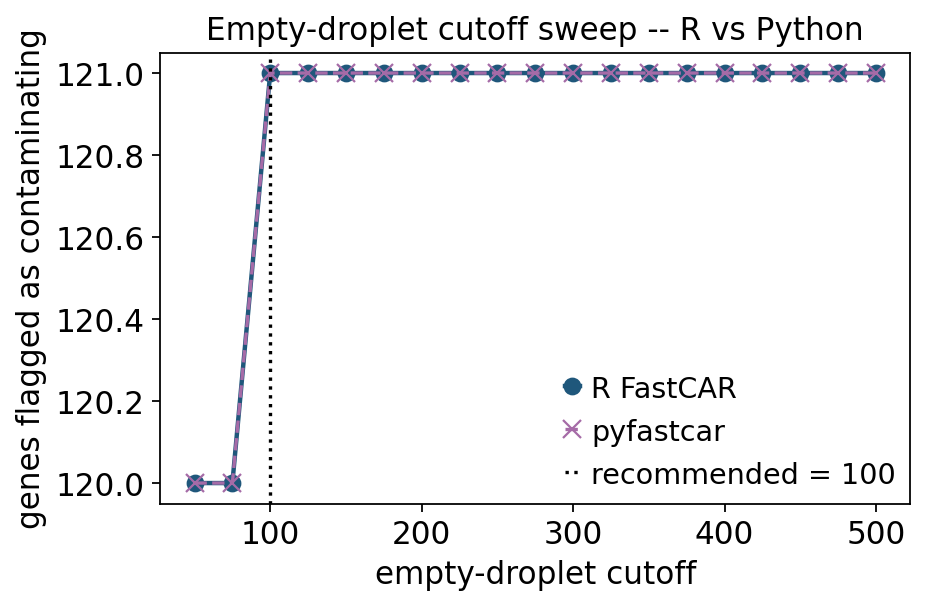

In [11]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(r_desc.index, r_desc["genesContaminating"], "o-",
        label="R FastCAR", ms=7, lw=2)
ax.plot(py_desc.index, py_desc["genesContaminating"], "x--",
        label="pyfastcar", ms=8, lw=1.5)
ax.axvline(fc.recommend_empty_cutoff(py_desc), c="k", ls=":",
           label=f"recommended = {fc.recommend_empty_cutoff(py_desc)}")
ax.set_xlabel("empty-droplet cutoff")
ax.set_ylabel("genes flagged as contaminating")
ax.set_title("Empty-droplet cutoff sweep -- R vs Python")
ax.legend()
plt.tight_layout(); plt.show()

## 11. UMAP before vs after correction -- `ov.pl.embedding`

Cluster the real cells with omicverse on the corrected counts and colour by
total ambient RNA removed per cell to see where the correction acts.

In [12]:
viz = corrected_ad.copy()
viz.layers["counts"] = viz.X.copy()
ambient_removed = np.asarray(cells.X.sum(1)).ravel() - np.asarray(viz.X.sum(1)).ravel()
viz.obs["ambient_removed"] = ambient_removed

ov.pp.preprocess(viz, mode="shiftlog|pearson", n_HVGs=2000)
viz.raw = viz
viz = viz[:, viz.var.highly_variable_features]
ov.pp.scale(viz)
ov.pp.pca(viz, layer="scaled", n_pcs=30)
ov.pp.neighbors(viz, n_neighbors=15, use_rep="scaled|original|X_pca")
ov.pp.leiden(viz, resolution=0.5)
ov.pp.umap(viz)
print(viz)

🔍 [2026-05-21 21:22:13] Running preprocessing in 'cpu' mode...
Begin robust gene identification
    After filtration, 4000/4000 genes are kept.
    Among 4000 genes, 4000 genes are robust.
✅ Robust gene identification completed successfully.
Begin size normalization: shiftlog and HVGs selection pearson

🔍 Count Normalization:
   Target sum: 500000.0
   Exclude highly expressed: True
   Max fraction threshold: 0.2
   ⚠️ Excluding 4 highly-expressed genes from normalization computation
   Excluded genes: ['IGKC', 'MALAT1', 'MT-CO1', 'MT-CO3']

✅ Count Normalization Completed Successfully!
   ✓ Processed: 1,171 cells × 4,000 genes
   ✓ Runtime: 0.05s

🔍 Highly Variable Genes Selection (Experimental):
   Method: pearson_residuals
   Target genes: 2,000
   Theta (overdispersion): 100



✅ Experimental HVG Selection Completed Successfully!
   ✓ Selected: 2,000 highly variable genes out of 4,000 total (50.0%)
   ✓ Results added to AnnData object:
     • 'highly_variable': Boolean vector (adata.var)
     • 'highly_variable_rank': Float vector (adata.var)
     • 'highly_variable_nbatches': Int vector (adata.var)
     • 'highly_variable_intersection': Boolean vector (adata.var)
     • 'means': Float vector (adata.var)
     • 'variances': Float vector (adata.var)
     • 'residual_variances': Float vector (adata.var)
    Time to analyze data in cpu: 3.43 seconds.
✅ Preprocessing completed successfully.
    Added:
        'highly_variable_features', boolean vector (adata.var)
        'means', float vector (adata.var)
        'variances', float vector (adata.var)
        'residual_variances', float vector (adata.var)
        'counts', raw counts layer (adata.layers)
    End of size normalization: shiftlog and HVGs selection pearson

╭─ SUMMARY: preprocess ────────────────────

   🔧 PCA solver used: covariance_eigh
    finished✅ (68.81s)

╭─ SUMMARY: pca ─────────────────────────────────────────────────────╮
│  Duration: 68.8116s                                                │
│  Shape:    1,171 x 2,000 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● UNS    │ ✚ pca                                                  │
│           │ └─ params: {'zero_center': True, 'use_highly_variable': Tr...│
│           │ ✚ scaled|original|cum_sum_eigenvalues                  │
│           │ ✚ scaled|original|pca_var_ratios                       │
│                                                                    │
│  ● OBSM   │ ✚ X_pca (array, 1171x30)                               │
│           │ ✚ scaled|original|X_pca (array, 1171x30)               │
│        

   🔍 Computing connectivity matrix...
   💡 Using UMAP-style connectivity


   ✓ Graph is fully connected

✅ KNN Graph Construction Completed Successfully!
   ✓ Processed: 1,171 cells with 15 neighbors each
   ✓ Results added to AnnData object:
     • 'neighbors': Neighbors metadata (adata.uns)
     • 'distances': Distance matrix (adata.obsp)
     • 'connectivities': Connectivity matrix (adata.obsp)

╭─ SUMMARY: neighbors ───────────────────────────────────────────────╮
│  Duration: 11.4108s                                                │
│  Shape:    1,171 x 2,000 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● UNS    │ ✚ neighbors                                            │
│           │ └─ params: {'n_neighbors': 15, 'method': 'umap', 'random_s...│
│                                                                    │
│  ● OBSP   │ ✚ connectivit


✅ UMAP Dimensionality Reduction Completed Successfully!
   ✓ Embedding shape: 1,171 cells × 2 dimensions
   ✓ Results added to AnnData object:
     • 'X_umap': UMAP coordinates (adata.obsm)
     • 'umap': UMAP parameters (adata.uns)
✅ UMAP completed successfully.

╭─ SUMMARY: umap ────────────────────────────────────────────────────╮
│  Duration: 0.987s                                                  │
│  Shape:    1,171 x 2,000 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● UNS    │ ✚ umap                                                 │
│           │ └─ params: {'a': np.float64(0.5830300203414425), 'b': np.f...│
│                                                                    │
│  ● OBSM   │ ✚ X_umap (array, 1171x2)                               │
│                 

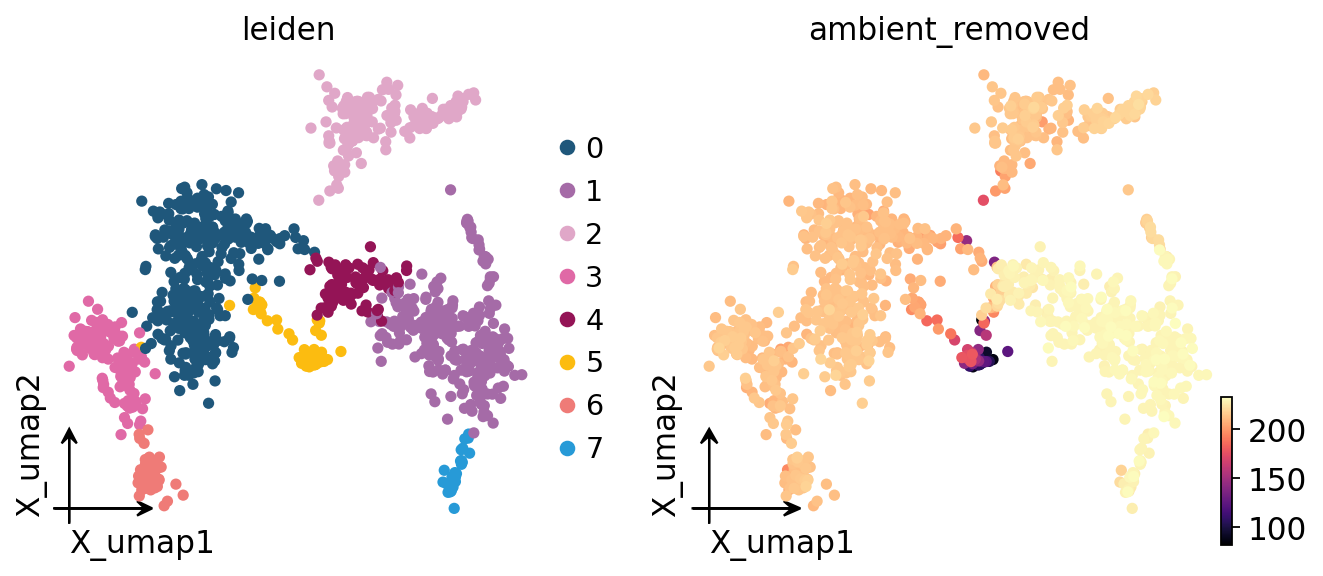

In [13]:
ov.pl.embedding(
    viz, basis="X_umap",
    color=["leiden", "ambient_removed"],
    cmap="magma", frameon="small", ncols=2, wspace=0.25, show=False,
)
plt.show()

## Summary

| Check | Expected | Observed |
|---|---|---|
| Ambient profile (per-gene gMax) | element-for-element equal | see cell 5 |
| Corrected count matrix | bit-identical integers | see cell 6 |
| Threshold-profiling table | bit-identical | see cell 7 |
| Recommended empty-droplet cutoff | identical | see cell 7 |

FastCAR is fully deterministic -- there is no RNG anywhere in the algorithm --
so `pyfastcar` reproduces R FastCAR **bit-for-bit**. The Python port needs no
R install and works natively on AnnData via `correct_anndata`.